100%|██████████| 9.91M/9.91M [00:00<00:00, 127MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 16.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 29.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.32MB/s]


Epoch 1 Loss: 18141.9
Epoch 2 Loss: 17166.7
Epoch 3 Loss: 16671.6
Epoch 4 Loss: 16150.8
Epoch 5 Loss: 15782.8


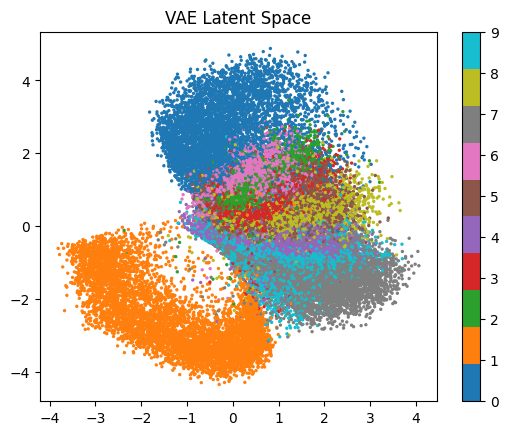

In [1]:
# pip install torch torchvision matplotlib
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ── Data ──
loader = DataLoader(datasets.MNIST("data", download=True,
                    transform=transforms.ToTensor()), batch_size=128)

# ── VAE Model ──
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(784,256), nn.ReLU())
        self.mu  = nn.Linear(256, 2)
        self.lv  = nn.Linear(256, 2)
        self.dec = nn.Sequential(nn.Linear(2,256), nn.ReLU(),
                                 nn.Linear(256,784), nn.Sigmoid())
    def forward(self, x):
        h = self.enc(x)
        mu, lv = self.mu(h), self.lv(h)
        z = mu + torch.exp(0.5*lv) * torch.randn_like(mu)   # reparameterization
        return self.dec(z), mu, lv

model = VAE()
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

# ── Train ──
for epoch in range(5):
    for x, _ in loader:
        recon, mu, lv = model(x)
        loss = nn.BCELoss(reduction='sum')(recon, x.view(-1,784)) \
               - 0.5 * (1 + lv - mu**2 - lv.exp()).sum()   # ELBO
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.1f}")

# ── Visualize Latent Space ──
zs, ys = [], []
with torch.no_grad():
    for x, y in loader:
        h = model.enc(x); zs.append(model.mu(h)); ys.append(y)

zs = torch.cat(zs).numpy(); ys = torch.cat(ys).numpy()
plt.scatter(zs[:,0], zs[:,1], c=ys, cmap="tab10", s=2)
plt.colorbar(); plt.title("VAE Latent Space"); plt.show()

Epoch 1 | D: 1.221 G: 0.722
Epoch 2 | D: 0.946 G: 1.254
Epoch 3 | D: 1.185 G: 0.871
Epoch 4 | D: 0.840 G: 1.262
Epoch 5 | D: 1.322 G: 0.702
Epoch 6 | D: 0.755 G: 1.151
Epoch 7 | D: 0.732 G: 1.324
Epoch 8 | D: 1.580 G: 0.747
Epoch 9 | D: 1.195 G: 1.008
Epoch 10 | D: 1.610 G: 0.665


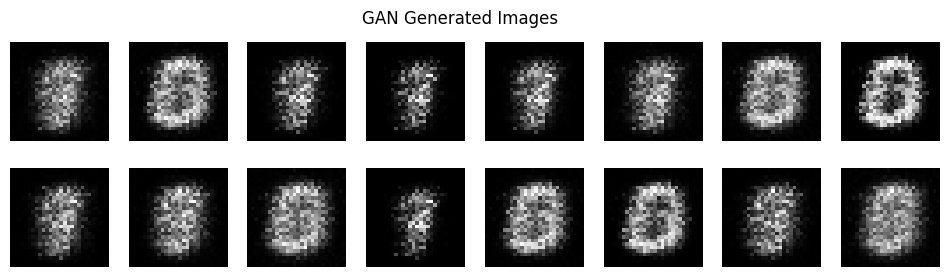

In [2]:
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

loader = DataLoader(datasets.MNIST("data", download=True,
                    transform=transforms.Compose([
                        transforms.ToTensor(),
                        transforms.Normalize((0.5,),(0.5,))])),
                    batch_size=64)

Z = 100  # noise dim

G = nn.Sequential(nn.Linear(Z,256), nn.ReLU(),
                   nn.Linear(256,784), nn.Tanh())          # Generator

D = nn.Sequential(nn.Linear(784,256), nn.LeakyReLU(0.2),
                   nn.Linear(256,1), nn.Sigmoid())         # Discriminator

opt_g = torch.optim.Adam(G.parameters(), lr=2e-4)
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4)
loss_fn = nn.BCELoss()

for epoch in range(10):
    for real, _ in loader:
        real = real.view(-1, 784)
        bs   = real.size(0)

        # Train D
        fake  = G(torch.randn(bs, Z))
        d_loss = loss_fn(D(real), torch.ones(bs,1)) + \
                 loss_fn(D(fake.detach()), torch.zeros(bs,1))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()

        # Train G
        g_loss = loss_fn(D(G(torch.randn(bs, Z))), torch.ones(bs,1))
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

    print(f"Epoch {epoch+1} | D: {d_loss.item():.3f} G: {g_loss.item():.3f}")

# ── Show generated images ──
imgs = G(torch.randn(16, Z)).detach().view(-1,28,28)
fig, axes = plt.subplots(2,8,figsize=(12,3))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i], cmap="gray"); ax.axis("off")
plt.suptitle("GAN Generated Images"); plt.show()

In [4]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.8 MB/s eta 0:00:00


In [5]:
# pip install torch torch-geometric
import torch, torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

data = Planetoid(root="data", name="Cora")[0]   # 2708 papers, 7 classes

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = GCNConv(data.num_features, 16)
        self.c2 = GCNConv(16, 7)                 # 7 = num classes in Cora

    def forward(self, x, edge_index):
        x = F.relu(self.c1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.c2(x, edge_index)

model = GCN()
opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# ── Train ──
for epoch in range(200):
    model.train()
    opt.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward(); opt.step()

# ── Test ──
model.eval()
pred = model(data.x, data.edge_index).argmax(dim=1)
acc  = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
print(f"Test Accuracy: {acc:.4f}")   # typically ~81%

Processing...
Done!


Test Accuracy: 0.8090
